In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class_mapping = {
    0: "bed",
    1: "sofa",
    2: "chair",
    3: "table",
    4: "lamp",
    5: "tv",
    6: "laptop",
    7: "wardrobe",
    8: "window",
    9: "door",
    10: "potted plant",
    11: "photo frame"
}

In [3]:
train_dir = "F:/homeobjects-3K/labels/train"
val_dir = "F:/homeobjects-3K/labels/val"

label_files = (
    [os.path.join(train_dir, f) for f in os.listdir(train_dir)] +
    [os.path.join(val_dir, f) for f in os.listdir(val_dir)]
)

In [4]:
class_counts = {class_name: 0 for class_name in class_mapping.values()}
for i, label_file in enumerate(label_files):
    with open(label_file, 'r') as f:
        anotations = [line for line in f.read().split("\n") if line.strip() != ""]
        class_ids = set([int(line.split(" ")[0]) for line in anotations])
        for class_id in class_ids:
            class_name = class_mapping[class_id]
            class_counts[class_name] += 1
print(class_counts)

{'bed': 169, 'sofa': 1760, 'chair': 1156, 'table': 1958, 'lamp': 1281, 'tv': 365, 'laptop': 90, 'wardrobe': 485, 'window': 884, 'door': 431, 'potted plant': 1902, 'photo frame': 1273}


In [5]:
class_counts = pd.Series(class_counts)
class_counts.sort_values(ascending=False)

table           1958
potted plant    1902
sofa            1760
lamp            1281
photo frame     1273
chair           1156
window           884
wardrobe         485
door             431
tv               365
bed              169
laptop            90
dtype: int64

In [6]:
class_counts.sum()

np.int64(11754)

<Axes: >

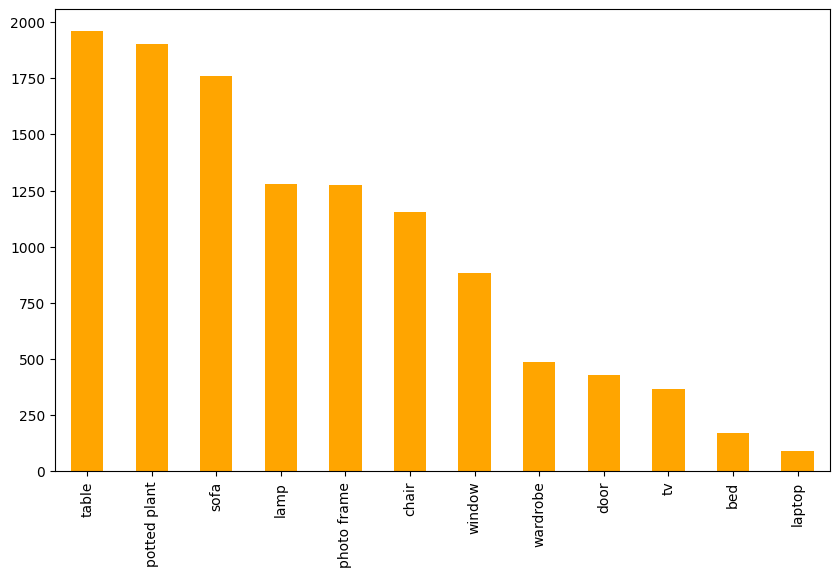

In [7]:
class_counts.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='orange')